In [80]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Import các thư viện mô hình
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from catboost import CatBoostClassifier

# Import thư viện đánh giá
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, accuracy_score

In [81]:
# 1. LOAD DỮ LIỆU
train_csv = pd.read_csv('../data/processed/train.csv')
valid_csv = pd.read_csv('../data/processed/valid.csv') # <--- MỚI
test_csv = pd.read_csv('../data/processed/test.csv')

print(f"Train size: {train_csv.shape}")
print(f"Valid size: {valid_csv.shape}")
print(f"Test size:  {test_csv.shape}")

Train size: (3187, 11)
Valid size: (563, 11)
Test size:  (662, 11)


In [82]:
# 2. TIỀN XỬ LÝ
target_col = "SOURCE"

# Hàm xử lý chung để đảm bảo nhất quán
def preprocess_data(df, is_train=False, train_columns=None):
    # Tách X, y
    X = df.drop(columns=[target_col])
    y = df[target_col].map({"in": 0, "out": 1}).astype(int)
    
    # One-Hot Encoding
    X = pd.get_dummies(X, drop_first=True)
    
    # Nếu không phải tập train, phải căn chỉnh cột theo tập train
    if not is_train:
        X = X.reindex(columns=train_columns, fill_value=0)
        
    return X, y

# Xử lý Train trước để lấy danh sách cột chuẩn
X_train, y_train = preprocess_data(train_csv, is_train=True)
train_cols = X_train.columns

# Xử lý Valid và Test theo cột của Train
X_valid, y_valid = preprocess_data(valid_csv, is_train=False, train_columns=train_cols)
X_test, y_test = preprocess_data(test_csv, is_train=False, train_columns=train_cols)

print("-" * 30)
print(f"X_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"X_test:  {X_test.shape}")

------------------------------
X_train: (3187, 10)
X_valid: (563, 10)
X_test:  (662, 10)


In [83]:
# 3. KHỞI TẠO CÁC MÔ HÌNH
models = {
    # --- Mô hình cơ bản (Baseline) ---
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=0.01, solver='liblinear'),
    
    # --- Mô hình cây đơn lẻ & Bagging ---
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10, criterion= 'gini', min_samples_split=2),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5, min_samples_leaf=4),
    
    # --- Mô hình Boosting (Họ hàng của XGBoost) ---
    "XGBoost (Lib)": xgb.XGBClassifier(
        n_estimators=100, 
        learning_rate=0.05, 
        max_depth=5, 
        random_state=42, 
        eval_metric='logloss'
    ),
    
    "CatBoost": CatBoostClassifier(
        iterations=100, 
        learning_rate=0.01, 
        depth=5, 
        random_seed=42, 
        verbose=0   # Tắt log in ra màn hình cho gọn
    )
}

In [84]:
# 4. HUẤN LUYỆN VÀ ĐÁNH GIÁ TOÀN DIỆN (ĐÃ CẬP NHẬT)
results = []
roc_curves = {} # Lưu dữ liệu để vẽ biểu đồ ROC sau này

print(f"{'Model':<20} | {'Train Acc':<10} | {'Test Acc':<10} | {'F1-Score':<10} | {'AUC':<10} | {'Overfit':<8}")
print("-" * 90)

for name, model in models.items():
    start_time = time.time()
    
    # Huấn luyện
    if name == "XGBoost (Lib)":
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    elif name == "CatBoost":
        model.fit(X_train, y_train, eval_set=(X_valid, y_valid))
    else:
        model.fit(X_train, y_train)
        
    train_time = time.time() - start_time
    
    # 1. Dự đoán nhãn (0 hoặc 1) để tính Accuracy, F1
    y_pred_train = model.predict(X_train)
    y_pred_valid = model.predict(X_valid)
    y_pred_test  = model.predict(X_test)
    
    # 2. Dự đoán xác suất (0.0 -> 1.0) để tính ROC-AUC
    # Lưu ý: Cần lấy cột index 1 (xác suất của lớp Positive/1)
    if hasattr(model, "predict_proba"):
        y_prob_test = model.predict_proba(X_test)[:, 1]
    else:
        # Trường hợp model không hỗ trợ predict_proba (hiếm gặp với các model này)
        y_prob_test = [0] * len(y_test)

    # 3. Tính toán các chỉ số
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_valid = accuracy_score(y_valid, y_pred_valid)
    acc_test  = accuracy_score(y_test, y_pred_test)
    
    f1_test   = f1_score(y_test, y_pred_test)
    auc_test  = roc_auc_score(y_test, y_prob_test)
    
    # Tính chỉ số Overfitting: Chênh lệch giữa Train và Test
    # Giá trị dương lớn -> Overfitting cao
    overfitting_score = acc_train - acc_test
    
    # Lưu lại để vẽ biểu đồ ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob_test)
    roc_curves[name] = (fpr, tpr, auc_test)

    results.append({
        "Model": name,
        "Train Acc": acc_train,
        "Valid Acc": acc_valid,
        "Test Acc": acc_test,
        "F1-Score": f1_test,
        "ROC-AUC": auc_test,
        "Overfitting": overfitting_score, # Càng thấp càng tốt
        "Time": train_time
    })
    
    print(f"{name:<20} | {acc_train:.4f}     | {acc_test:.4f}     | {f1_test:.4f}     | {auc_test:.4f}     | {overfitting_score:.4f}")


Model                | Train Acc  | Test Acc   | F1-Score   | AUC        | Overfit 
------------------------------------------------------------------------------------------
Logistic Regression  | 0.7198     | 0.7281     | 0.7931     | 0.7761     | -0.0083
Decision Tree        | 0.8644     | 0.7024     | 0.7559     | 0.7049     | 0.1620
Random Forest        | 0.7713     | 0.7296     | 0.7906     | 0.7944     | 0.0417
XGBoost (Lib)        | 0.8259     | 0.7508     | 0.8043     | 0.8175     | 0.0751
CatBoost             | 0.7430     | 0.7311     | 0.7930     | 0.7896     | 0.0119


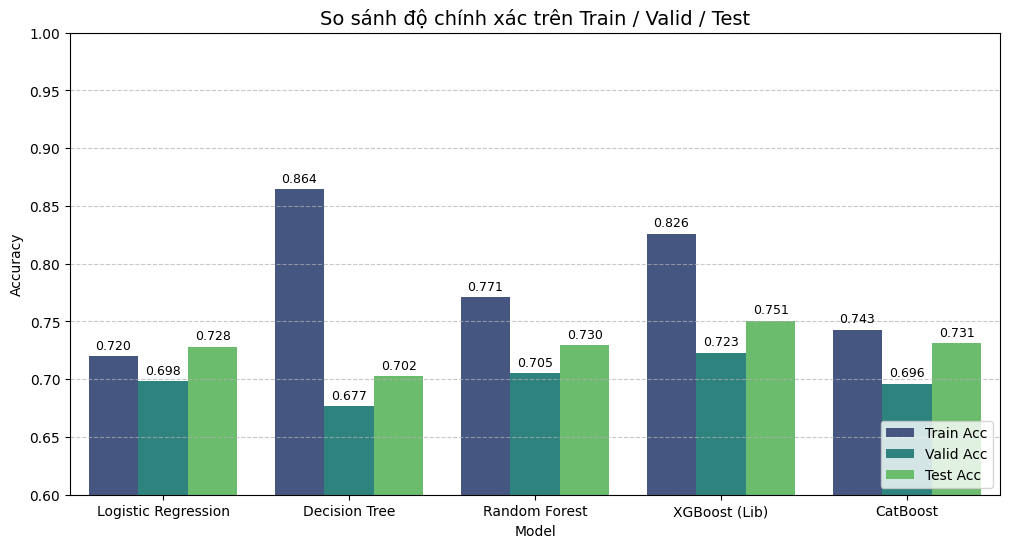

In [85]:
# 5. BIỂU ĐỒ 1: SO SÁNH ĐỘ CHÍNH XÁC TRAIN / VALID / TEST (GIỐNG ẢNH MẪU)
df_res = pd.DataFrame(results)

# Chuyển dữ liệu sang dạng dài (Long format) để vẽ Group Bar Chart
# Chúng ta chọn 3 chỉ số này để khớp với biểu đồ mẫu bạn yêu cầu
metrics_to_plot = ["Train Acc", "Valid Acc", "Test Acc"]

df_melt = df_res.melt(id_vars="Model", 
                      value_vars=metrics_to_plot, 
                      var_name="Dataset", 
                      value_name="Accuracy")

plt.figure(figsize=(12, 6))

# Sử dụng palette='viridis' để có màu Xanh đậm -> Xanh lá như trong ảnh
ax = sns.barplot(data=df_melt, x="Model", y="Accuracy", hue="Dataset", palette="viridis")

# Trang trí biểu đồ giống mẫu
plt.title("So sánh độ chính xác trên Train / Valid / Test", fontsize=14)
plt.ylim(0.6, 1.0) # Giới hạn trục Y từ 0.6 đến 1.0
plt.legend(loc='lower right') # Chú thích nằm góc dưới phải
plt.grid(axis='y', linestyle='--', alpha=0.7) # Kẻ ngang nét đứt

# Hiển thị số liệu trên cột với 3 chữ số thập phân (%.3f)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_1672\63410000.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--', color='gray') # Đường ngẫu nhiên
C:\Users\HP\AppData\Local\Temp\ipykernel_1672\63410000.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--', color='gray') # Đường ngẫu nhiên


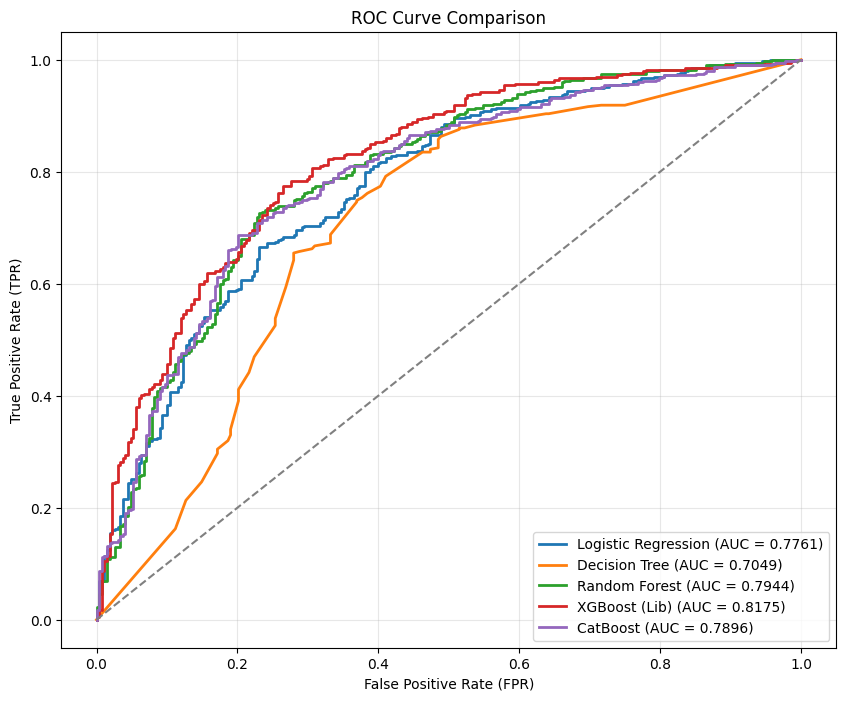

In [86]:
# 6. BIỂU ĐỒ 2: ĐƯỜNG CONG ROC (ROC CURVE)
plt.figure(figsize=(10, 8))

for name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linestyle='--', color='gray') # Đường ngẫu nhiên
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_1672\3960190038.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_res, x="Model", y="Overfitting", palette="Reds")


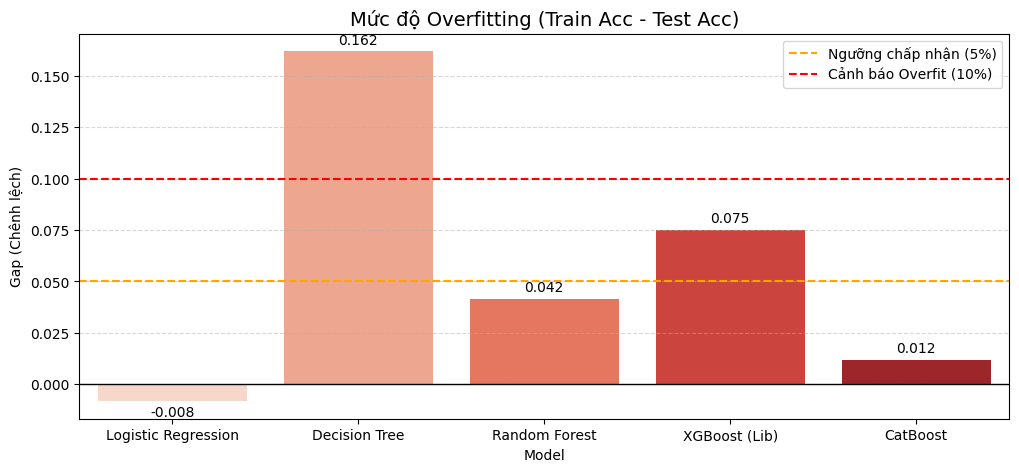


KẾT LUẬN:
- ROC-AUC: Đánh giá khả năng phân loại tổng quát (bất kể ngưỡng). Model nào đường cong càng lồi về góc trái trên càng tốt.
- F1-Score: Quan trọng nếu dữ liệu bị mất cân bằng (Imbalanced Data).
- Overfitting: Cột màu đỏ càng cao nghĩa là Model học vẹt trên tập Train nhưng kém trên Test.


In [87]:
# 7. BIỂU ĐỒ 3: ĐÁNH GIÁ OVERFITTING (Train Acc - Test Acc)
# Gap càng cao -> Overfitting càng nặng
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=df_res, x="Model", y="Overfitting", palette="Reds")

plt.title("Mức độ Overfitting (Train Acc - Test Acc)", fontsize=14)
plt.ylabel("Gap (Chênh lệch)")
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm ngưỡng cảnh báo
plt.axhline(0.05, color='orange', linestyle='--', label='Ngưỡng chấp nhận (5%)')
plt.axhline(0.10, color='red', linestyle='--', label='Cảnh báo Overfit (10%)')
plt.legend()

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.show()

print("\nKẾT LUẬN:")
print("- ROC-AUC: Đánh giá khả năng phân loại tổng quát (bất kể ngưỡng). Model nào đường cong càng lồi về góc trái trên càng tốt.")
print("- F1-Score: Quan trọng nếu dữ liệu bị mất cân bằng (Imbalanced Data).")
print("- Overfitting: Cột màu đỏ càng cao nghĩa là Model học vẹt trên tập Train nhưng kém trên Test.")

C:\Users\HP\AppData\Local\Temp\ipykernel_1672\2637585886.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_res, x="Model", y="F1-Score", palette="magma")


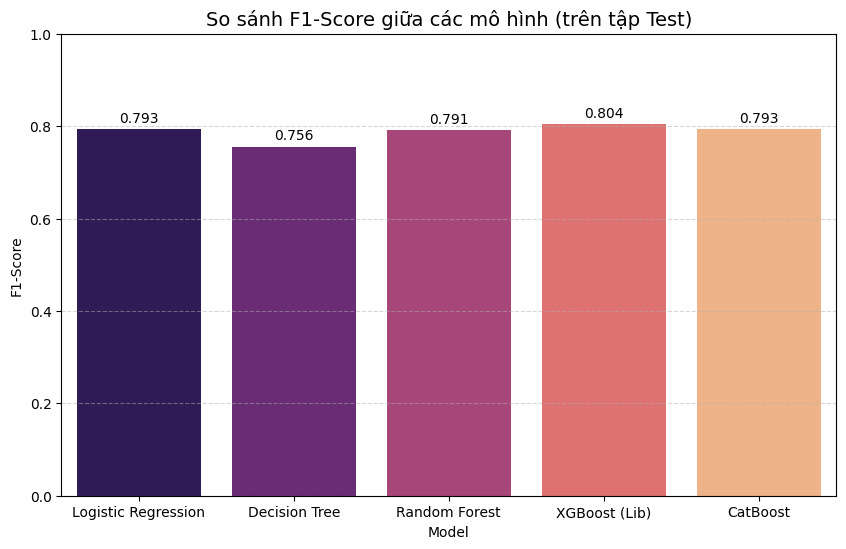

In [88]:
# 6. BIỂU ĐỒ 2: SO SÁNH F1-SCORE (MỚI)
# F1-Score là trung bình điều hòa giữa Precision và Recall, quan trọng khi dữ liệu mất cân bằng
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_res, x="Model", y="F1-Score", palette="magma")

plt.title("So sánh F1-Score giữa các mô hình (trên tập Test)", fontsize=14)
plt.ylabel("F1-Score")
plt.ylim(0, 1.0) # F1 cũng nằm trong khoảng 0-1
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Hiển thị số liệu
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.show()